<a href="https://colab.research.google.com/github/ekstrandlab/NeuroFaceCNN/blob/main/Scripts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Model Info

In [91]:
!pip -q install tf-keras h5py pydot graphviz
import tensorflow as tf
import keras
import tf_keras

import sys
print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("Keras (v3):", keras.__version__)
print("tf_keras (v2-compat):", tf_keras.__version__)


Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
TensorFlow: 2.19.0
Keras (v3): 3.10.0
tf_keras (v2-compat): 2.19.0


In [92]:
from google.colab import files
uploaded = files.upload()  # choose model82 and weights

Saving model82_weights.h5 to model82_weights (1).h5
Saving model82.h5 to model82.h5


In [93]:
import os
MODEL_PATH = "model82.h5"
WEIGHTS_PATH = "model82_weights.h5"

model = tf_keras.models.load_model(MODEL_PATH, compile=False)
print("Loaded model from:", MODEL_PATH)

# overwrite weights using WEIGHTS_PATH
if os.path.exists(WEIGHTS_PATH):
    try:
        model.load_weights(WEIGHTS_PATH)
        print("Loaded weights from:", WEIGHTS_PATH)
    except Exception as e:
        print("Weights file not loaded (maybe mismatch):", e)

print("\n  MODEL SUMMARY  ")
model.summary()


Loaded model from: model82.h5
Loaded weights from: model82_weights.h5

  MODEL SUMMARY  
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 41489, 10, 64)     1024      
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 41489, 10, 64)     0         
                                                                 
 batch_normalization (Batch  (None, 41489, 10, 64)     256       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 20744, 10, 64)     0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 20744, 10, 64)     0         
                                 

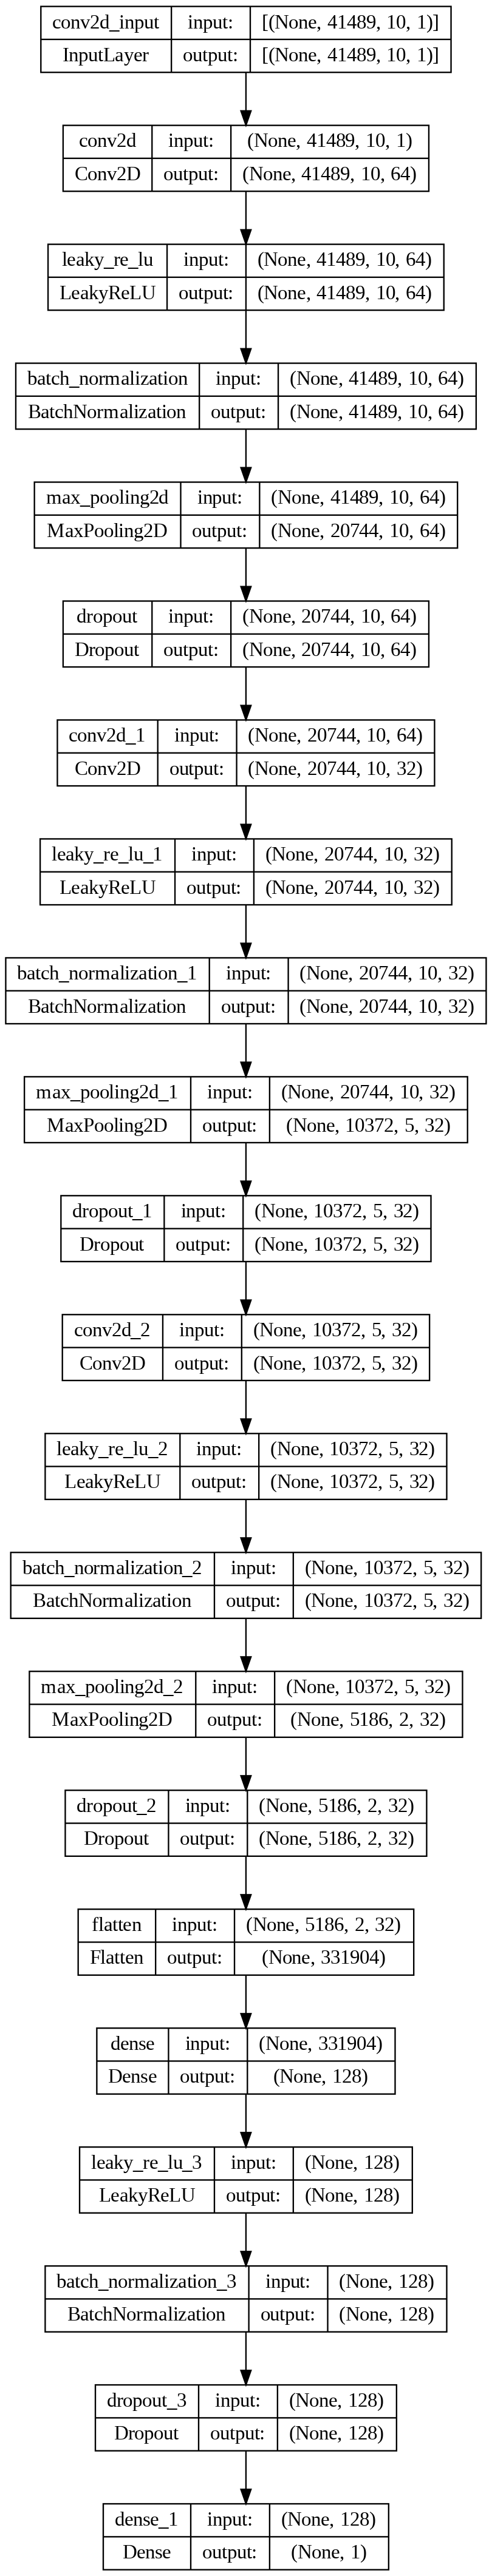

In [94]:
from tf_keras.utils import plot_model
from IPython.display import Image, display

plot_model(
    model,
    to_file="model_arch.png",
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True,
    dpi=170
)

display(Image("model_arch.png"))


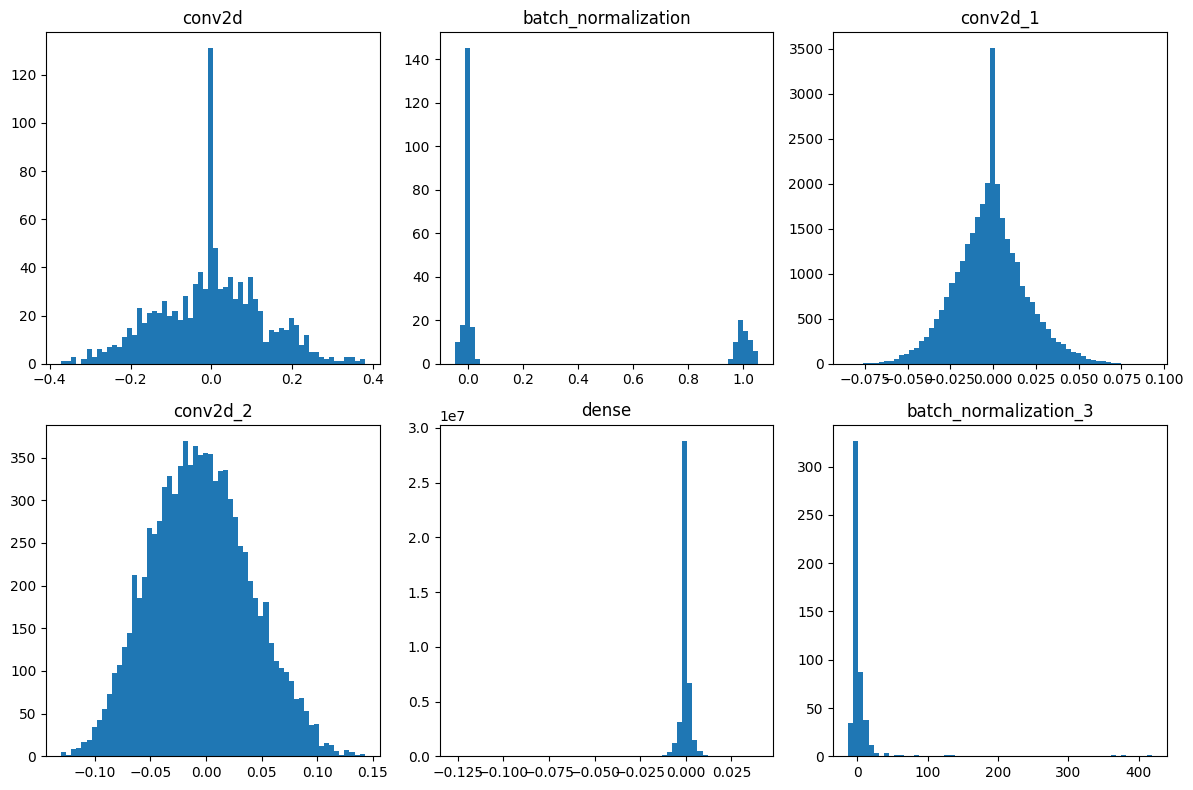

In [95]:
# pick top layers by parameter count
top_k = 6
top_layers = [layer_names_sorted[i] for i in range(min(top_k, len(layer_names_sorted)))]

plt.figure(figsize=(12, 8))
plot_i = 1
for layer in model.layers:
    if layer.name in top_layers:
        wts = layer.get_weights()
        if len(wts) == 0:
            continue
        w_flat = np.concatenate([w.flatten() for w in wts if w is not None and w.size > 0])
        plt.subplot(2, 3, plot_i)
        plt.hist(w_flat, bins=60)
        plt.title(layer.name)
        plot_i += 1
        if plot_i > 6:
            break

plt.tight_layout()
plt.show()


## IG Visulisation for Single trial

In [105]:
del uploaded

In [106]:
!pip -q install nibabel nilearn

from google.colab import files
uploaded = files.upload()
print("Uploaded:", list(uploaded.keys()))


Saving sub-31_face_avg_IG.nii.gz to sub-31_face_avg_IG.nii (1).gz
Saving face ffa_association-test_z_FDR_0.01.nii to face ffa_association-test_z_FDR_0.01 (4).nii
Uploaded: ['sub-31_face_avg_IG.nii (1).gz', 'face ffa_association-test_z_FDR_0.01 (4).nii']


In [109]:
import os
from pathlib import Path

BASE_OUT_DIR = Path("/content/IG")
BASE_OUT_DIR.mkdir(parents=True, exist_ok=True)

uploaded_list = list(uploaded.keys())

FFA_FILE = [f for f in uploaded_list
            if "ffa" in f.lower() and f.lower().endswith((".nii", ".nii.gz"))][0]

IG_FILE  = [f for f in uploaded_list
            if "ig" in f.lower() and f.lower().endswith((".nii", ".nii.gz", ".gz"))][0]

print("Detected FFA mask:", FFA_FILE)
print("Detected IG file :", IG_FILE)

ffa_dst = BASE_OUT_DIR / "ffa_association-test_z_FDR_0.01.nii"
ig_dst  = BASE_OUT_DIR / "IG_input.nii.gz"

for dst in [ffa_dst, ig_dst]:
    if dst.exists():
        dst.unlink()

os.rename(f"/content/{FFA_FILE}", str(ffa_dst))
os.rename(f"/content/{IG_FILE}",  str(ig_dst))

print("Ready paths:")
print(" -", ffa_dst, "| exists:", ffa_dst.exists())
print(" -", ig_dst,  "| exists:", ig_dst.exists())


Detected FFA mask: face ffa_association-test_z_FDR_0.01 (4).nii
Detected IG file : sub-31_face_avg_IG.nii (1).gz
Ready paths:
 - /content/IG/ffa_association-test_z_FDR_0.01.nii | exists: True
 - /content/IG/IG_input.nii.gz | exists: True


In [110]:
!ls -lah /content/IG

total 21M
drwxr-xr-x 2 root root 4.0K Jan 20 01:48  .
drwxr-xr-x 1 root root 4.0K Jan 20 01:48  ..
-rw-r--r-- 1 root root 4.8M Jan 20 01:02 '0-new-threshold-ventral_IG Map.png'
-rw-r--r-- 1 root root 6.9M Jan 20 00:41 'face ffa_association-test_z_FDR_0.01 (1).nii'
-rw-r--r-- 1 root root 6.9M Jan 20 01:47  ffa_association-test_z_FDR_0.01.nii
-rw-r--r-- 1 root root 1.9M Jan 20 01:47  IG_input.nii.gz


In [116]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn import plotting, surface, datasets, image
from scipy.ndimage import binary_erosion
from pathlib import Path

BASE_OUT_DIR = Path("/content/IG")
data_paths = {"IG Map": BASE_OUT_DIR / "IG_input.nii.gz"}

ffa_mask_path = str(BASE_OUT_DIR / "ffa_association-test_z_FDR_0.01.nii")
ffa_threshold = 0.4
erosion_iter = 2
display_percentile = 0
cmap = "RdBu"
out_png = "0-new-threshold-ventral.png"

temp_dir = BASE_OUT_DIR / "temp_surf_images"
temp_dir.mkdir(exist_ok=True)

# HELPERS
def load_imgs(paths_dict):
    return {name: nib.load(str(p)) for name, p in paths_dict.items()}

def make_eroded_mask(mask_file, iterations):
    mimg = nib.load(mask_file)
    mask = mimg.get_fdata() > 0
    erode = binary_erosion(mask, iterations=iterations)
    return nib.Nifti1Image(erode.astype(float), mimg.affine)

def proj_mask_to_surf(mask_img, fs, hemi):
    mesh = fs.pial_left if hemi == "left" else fs.pial_right
    # FIX: nilearn API change
    proj = surface.vol_to_surf(mask_img, mesh, interpolation="nearest_most_frequent")
    return (proj > ffa_threshold).astype(float)

def proj_vol_to_surf_t(nii4d, t, fs, hemi):
    mesh = fs.pial_left if hemi == "left" else fs.pial_right
    return surface.vol_to_surf(image.index_img(nii4d, t), mesh)

def crop_whitespace(rgb):
    img = np.fliplr(np.rot90(rgb, 3))
    gray = img.mean(axis=2)
    keep = gray < 0.98
    if not np.any(keep):
        return img
    ys, xs = np.where(keep)
    return img[ys.min():ys.max()+1, xs.min():xs.max()+1, :]

def surf_figure(fs, hemi, tex, thresh, title=None):
    infl = fs.infl_left if hemi == "left" else fs.infl_right
    sulc = fs.sulc_left if hemi == "left" else fs.sulc_right
    fig = plotting.plot_surf_stat_map(
        infl, tex, hemi=hemi, view="ventral",
        threshold=thresh, cmap=cmap, bg_map=sulc,
        colorbar=False, figure=plt.figure(dpi=150)
    )
    if title:
        fig.axes[0].set_title(title, fontsize=10)
    return fig

def add_mask_contour(fs, hemi, mask_vertices, fig):
    if np.count_nonzero(mask_vertices) == 0:
        return
    infl = fs.infl_left if hemi == "left" else fs.infl_right
    try:
        plotting.plot_surf_contours(
            infl, mask_vertices,
            levels=[1], colors=["lime"],
            linewidths=0.005, figure=fig
        )
    except ValueError:
        plotting.plot_surf_stat_map(
            infl, mask_vertices, hemi=hemi, view="ventral",
            threshold=0.5, cmap="Greens", alpha=0.1,
            colorbar=False, figure=fig
        )

def safe_percentile(arr, p):
    arr = np.asarray(arr)
    arr = arr[np.nonzero(arr)]
    return np.percentile(np.abs(arr), p) if arr.size else 0.0

# RUN
fs = datasets.fetch_surf_fsaverage()
imgs = load_imgs(data_paths)

print("IG shape:", imgs["IG Map"].shape)
n_tp = imgs["IG Map"].shape[-1]

ffa_mask_img = make_eroded_mask(ffa_mask_path, erosion_iter)
ffa_surf = {hemi: proj_mask_to_surf(ffa_mask_img, fs, hemi) for hemi in ("left", "right")}

saved_files = []

for cond, nii in imgs.items():
    ncols = int(np.ceil(np.sqrt(n_tp)))
    nrows = int(np.ceil(n_tp / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3 * ncols, 3 * nrows),
        gridspec_kw={"wspace": 0.05, "hspace": 0.0}
    )

    if n_tp == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = axes.reshape(1, -1)
    elif ncols == 1:
        axes = axes.reshape(-1, 1)

    fig.suptitle(f"{cond} Subject 33", fontsize=16, fontweight="bold", y=0.98)

    items_in_last_row = n_tp % ncols if n_tp % ncols != 0 else ncols
    last_row_start_col = (ncols - items_in_last_row) // 2

    for t in range(n_tp):
        row = t // ncols
        col = t % ncols
        if row == nrows - 1 and items_in_last_row < ncols:
            col += last_row_start_col

        crops = []
        for hemi in ("left", "right"):
            tex = proj_vol_to_surf_t(nii, t, fs, hemi)
            thresh = safe_percentile(tex, display_percentile)
            f = surf_figure(fs, hemi, tex, thresh)
            add_mask_contour(fs, hemi, ffa_surf[hemi], f)
            tmp = temp_dir / f"{cond}_{hemi}_t{t}.png"
            plt.savefig(tmp, bbox_inches="tight")
            plt.close()
            rgb = plt.imread(tmp)[..., :3]
            crops.append(crop_whitespace(rgb))

        h = min(c.shape[0] for c in crops)
        w = min(c.shape[1] for c in crops)
        crops = [c[:h, :w] for c in crops]
        panel = np.concatenate(crops, axis=1)

        ax = axes[row, col]
        ax.imshow(panel)
        ax.axis("off")
        ax.text(0.5, 1.01, f"T={t+1}", ha="center", va="bottom", fontsize=10, fontweight="bold", transform=ax.transAxes)
        ax.text(0.25, -0.01, "L", ha="center", va="top", fontsize=9, fontweight="bold", transform=ax.transAxes)
        ax.text(0.75, -0.01, "R", ha="center", va="top",fontsize=9, fontweight="bold", transform=ax.transAxes)

    for r in range(nrows):
      for c in range(ncols):
          if not axes[r, c].has_data():
              axes[r, c].axis("off")

    out_file = BASE_OUT_DIR / out_png.replace(".png", f"_{cond}.png")

    out_file = BASE_OUT_DIR / out_png.replace(".png", f"_{cond}.png")
    fig.savefig(out_file, dpi=500, bbox_inches="tight")
    plt.close(fig)
    print("Saved:", out_file)
    saved_files.append(str(out_file))

# cleanup
for p in temp_dir.glob("*.png"):
    p.unlink()
temp_dir.rmdir()

saved_files


IG shape: (85, 85, 85, 10)
Saved: /content/IG/0-new-threshold-ventral_IG Map.png


['/content/IG/0-new-threshold-ventral_IG Map.png']

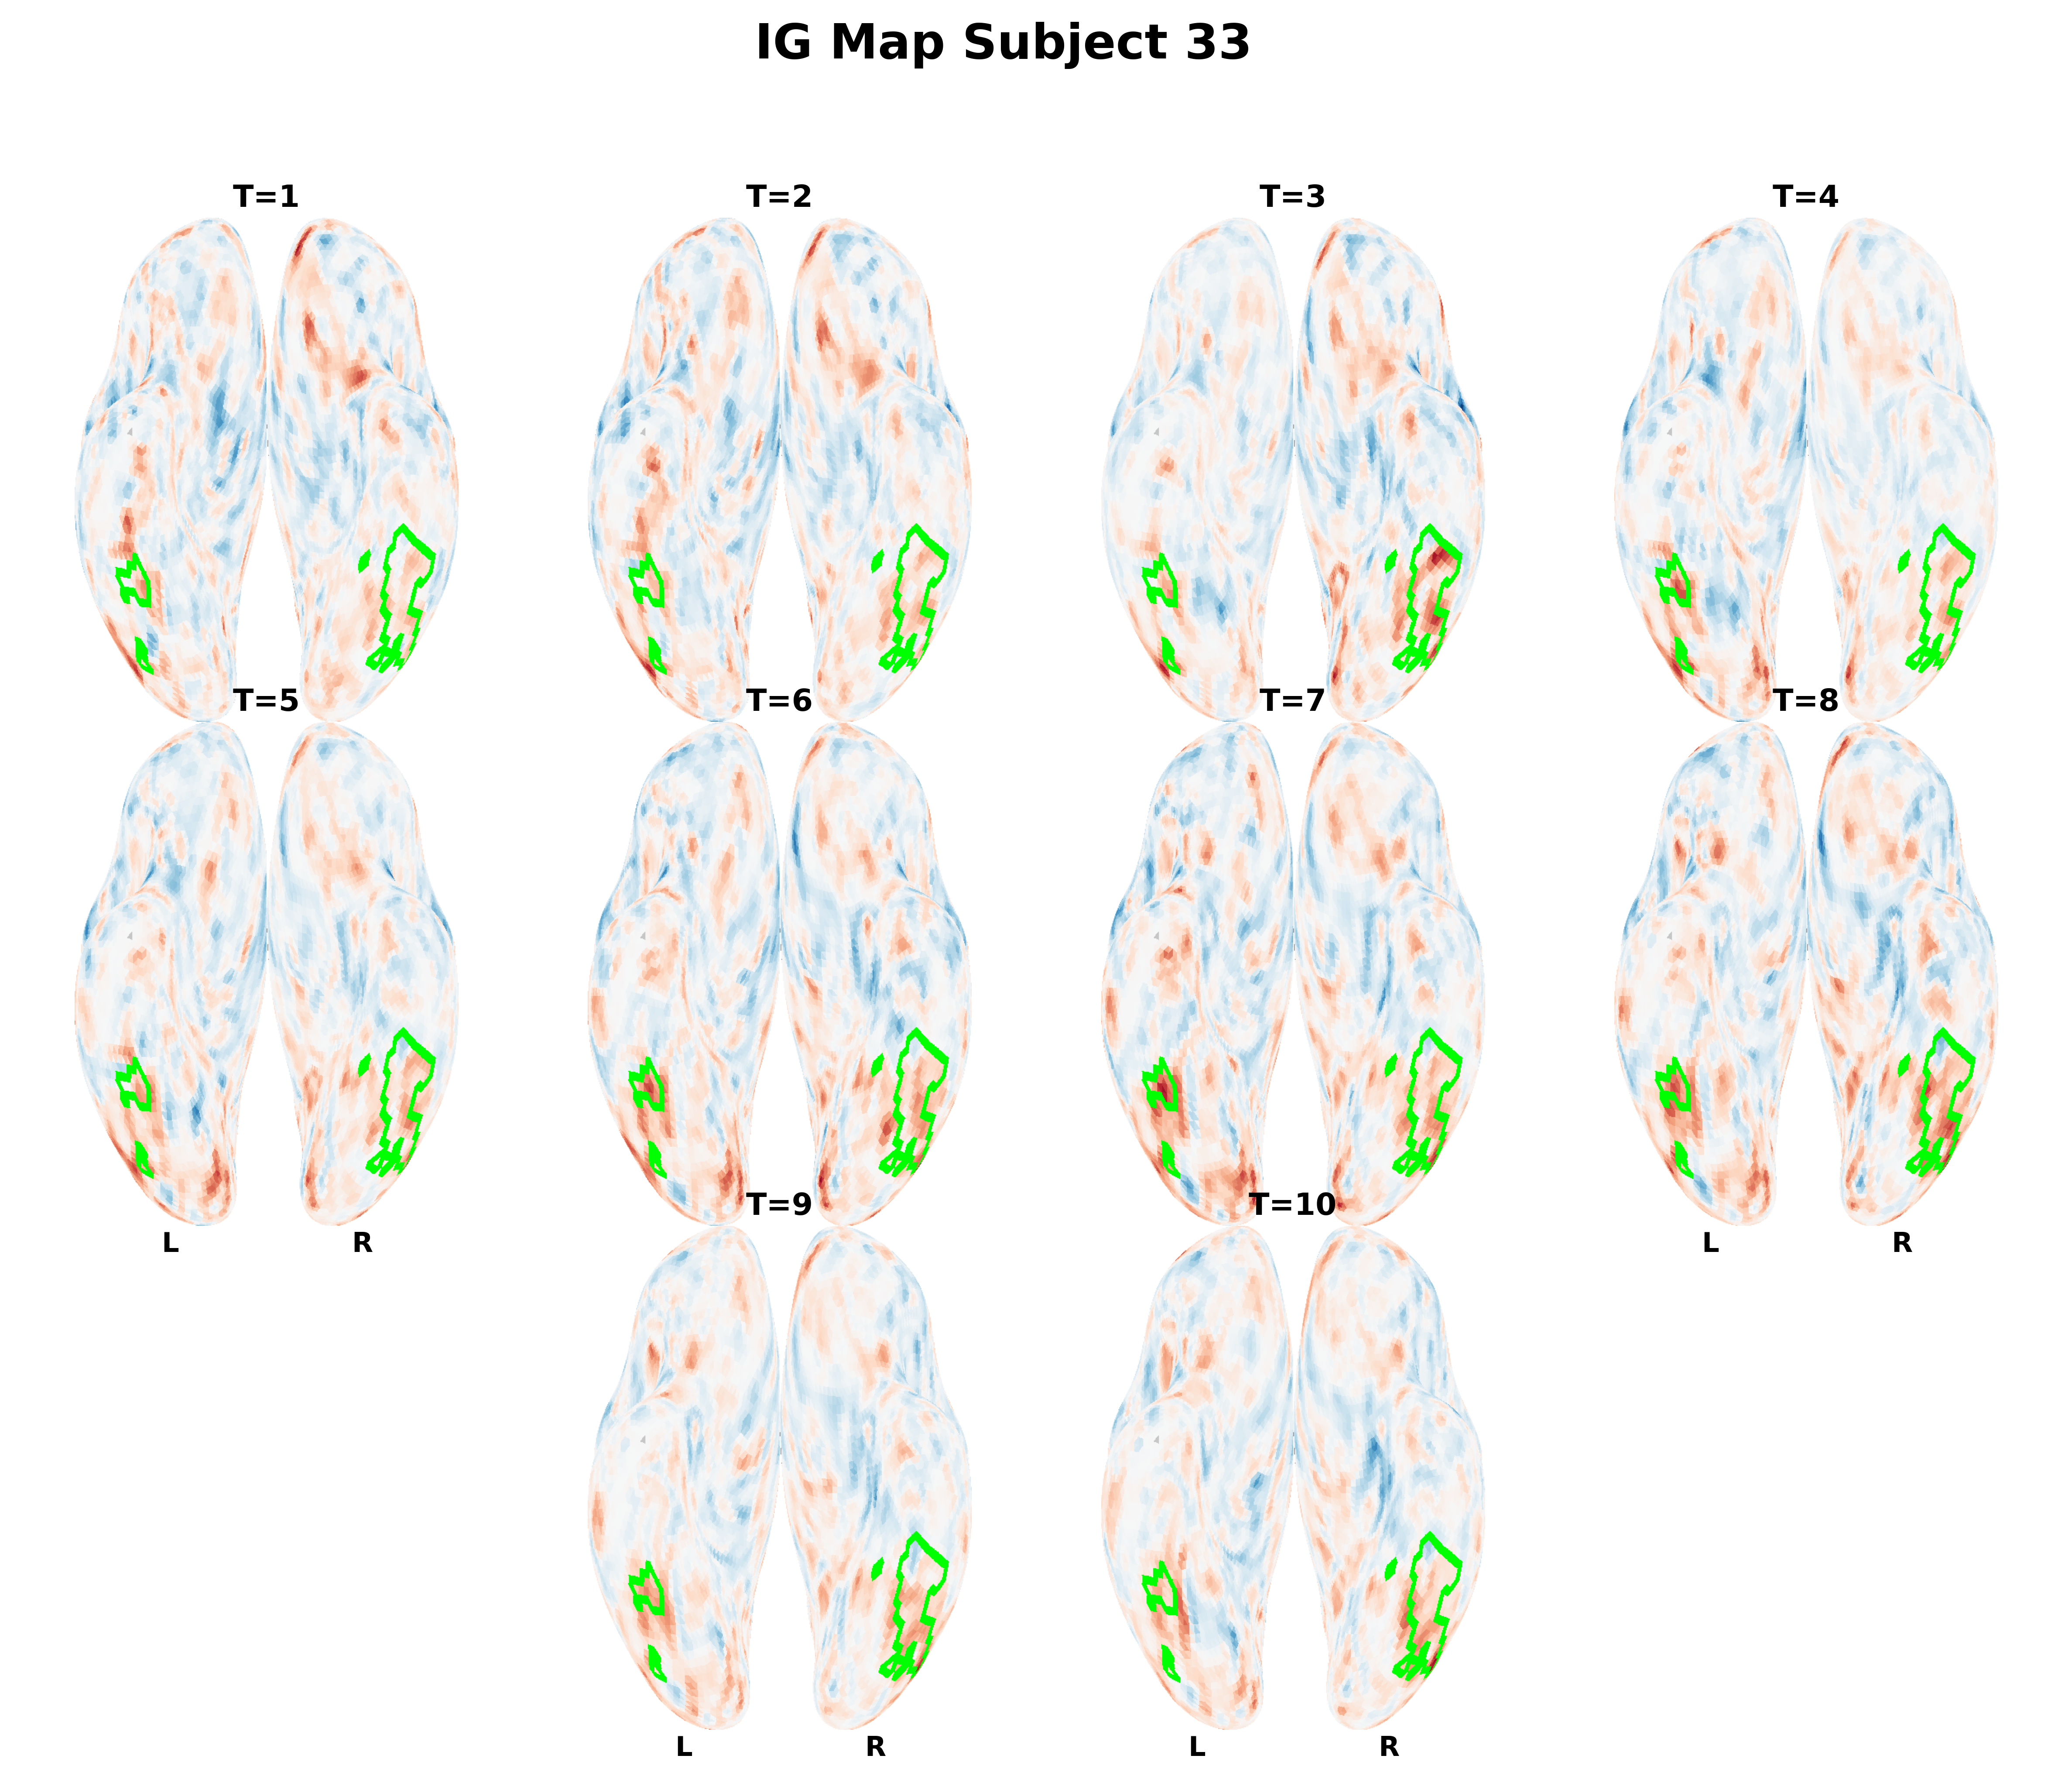

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [117]:
from IPython.display import Image, display
from google.colab import files

for f in saved_files:
    display(Image(filename=f))
    files.download(f)


## Moment by moment analysis

In [ ]:
!pip -q install nibabel scikit-learn

from google.colab import files
uploaded = files.upload()
print("Uploaded:", list(uploaded.keys()))


In [ ]:
import os
from pathlib import Path

# output
OUT_DIR = Path("/content/results")
OUT_DIR.mkdir(exist_ok=True)

uploaded_list = list(uploaded.keys())

def pick_file(contains=None, endswith=None):
    cands = uploaded_list
    if contains is not None:
        contains_l = contains.lower()
        cands = [f for f in cands if contains_l in f.lower()]
    if endswith is not None:
        if isinstance(endswith, str):
            ends = (endswith,)
        else:
            ends = tuple(endswith)
        cands = [f for f in cands if f.endswith(ends)]
    if len(cands) == 0:
        raise ValueError(f"Could not find file: contains={contains}, endswith={endswith}")
    return cands[0]

MODEL_FILE  = "/content/" + pick_file(contains="model", endswith=(".h5", ".keras"))
FMRI_FILE   = "/content/" + pick_file(contains="bold", endswith=(".nii.gz", ".nii"))
MASK_PATH   = "/content/" + pick_file(contains="mask", endswith=(".nii.gz", ".nii"))
EVENTS_FILE = "/content/" + pick_file(contains="annotation", endswith=(".txt", ".tsv", ".1d"))

print("MODEL_FILE :", MODEL_FILE)
print("FMRI_FILE  :", FMRI_FILE)
print("MASK_PATH  :", MASK_PATH)
print("EVENTS_FILE:", EVENTS_FILE)
print("OUT_DIR    :", OUT_DIR)


In [ ]:
import numpy as np
import nibabel as nib
import tensorflow as tf
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# fMRI + CNN params
TR   = 1.0
LAG  = 4          # seconds
WIN  = 10         # timepoints
STEP = 1


In [ ]:
print("Loading ground truth events...")
events_data = np.loadtxt(EVENTS_FILE)
gt_onsets_unshifted = events_data[:, 0]
gt_durations        = events_data[:, 1]
print(f"Loaded {len(gt_onsets_unshifted)} events")

def create_ground_truth_timeline(onsets, durations, t_axis):
    """Binary ground truth aligned to a given time axis."""
    gt = np.zeros(len(t_axis))
    for onset, duration in zip(onsets, durations):
        end = onset + duration
        idx = np.where((t_axis >= onset) & (t_axis < end))[0]
        gt[idx] = 1
    return gt


In [ ]:
print("Loading model...")
model = tf.keras.models.load_model(MODEL_FILE)

print("Loading mask...")
mask_img = nib.load(MASK_PATH).get_fdata()
mask_idx = np.where(mask_img.reshape(-1) > 0.99)[0]
print("Mask voxels kept:", len(mask_idx))

print("Loading fMRI...")
fmri = nib.load(FMRI_FILE).get_fdata()
X, Y, Z, T = fmri.shape
print("fMRI shape:", fmri.shape)

flat = fmri.reshape(-1, T)
masked_full = flat[mask_idx, :]
np.save(OUT_DIR / "full_vox_by_time.npy", masked_full)

print("Saved full vox_by_time:", OUT_DIR / "full_vox_by_time.npy")


In [ ]:
bold_start = LAG
bold_end   = T

segment = masked_full[:, bold_start:bold_end]
print("Lagged full-movie segment:", segment.shape)
np.save(OUT_DIR / "lagged_full_movie.npy", segment)

windows = []
times   = []

for t in range(0, segment.shape[1] - WIN + 1, STEP):
    win = segment[:, t:t + WIN]
    windows.append(win)

    win_start_bold = bold_start + t
    win_start_time = win_start_bold * TR
    times.append(win_start_time)

windows = np.array(windows, dtype=np.float32)
times   = np.array(times, dtype=float)

print("Windows:", windows.shape)
print("Time range:", times.min(), "→", times.max())

# CNN expects channel dim
windows = windows[..., np.newaxis]  # (N, vox, WIN, 1)


In [ ]:
preds = model.predict(windows, batch_size=16).reshape(-1)
binary_preds = (preds >= 0.5).astype(int)

np.save(OUT_DIR / "predictions.npy", preds)
np.save(OUT_DIR / "predictions_binary.npy", binary_preds)

print("Saved predictions to:", OUT_DIR)


In [ ]:
gt_binary = create_ground_truth_timeline(
    gt_onsets_unshifted,
    gt_durations,
    times
)

precision = precision_score(gt_binary, binary_preds)
recall    = recall_score(gt_binary, binary_preds)
f1        = f1_score(gt_binary, binary_preds)

print("\nMETRICS:")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")


In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(times, preds, label="CNN Probability", color="blue", linewidth=0.3)
ax.fill_between(times, 0, gt_binary, color="green", alpha=0.3, label="GT")
ax.axhline(0.5, linestyle="--", color="red", alpha=0.5)
ax.set_xlabel("Time (s, lagged BOLD)")
ax.set_ylabel("P(face)")
ax.set_title("Full-Movie Prediction vs Ground Truth")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
prob_png = OUT_DIR / "plot_probability_full_movie.png"
plt.savefig(prob_png)
plt.close()
print("Saved:", prob_png)


In [ ]:
from IPython.display import Image, display
from google.colab import files

display(Image(filename=str(prob_png)))
display(Image(filename=str(bin_png)))

files.download(str(prob_png))
files.download(str(bin_png))

# optional: download arrays too
for f in ["predictions.npy", "predictions_binary.npy", "lagged_full_movie.npy", "full_vox_by_time.npy"]:
    p = OUT_DIR / f
    if p.exists():
        files.download(str(p))
